### Introduction

- Model: **amd/DeepSeek-R1-MXFP4**

- Inference Server: **SGLang** and **vLLM**

- Six different server configurations on MI350x8 were evaluated using sglang.bench_serving, with input length 5600 and output length 140, and the number of prompts ranging from 1 to 40.

- The latest SGLang v0.5.9 outperforms vLLM v0.16.0 by nearly 100% in QPS, as the latter may have not yet incorporated the latest kernel optimizations.

- Enabling speculative decoding in SGLang can further increase QPS by approximately 50%.

- TP4 with SGLang achieves less than 50% of the performance of TP8. Enabling EP and DP Attention further reduces throughput, indicating that DeepSeek is compute-bound in this setup.


| No | Description | Version | Deployment |
|----------|----------|----------|---------- |
| 1    | TP8, MTP     | SGLang v0.5.9, ROCm 7.2    | https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260318/tp8-sglang-350-mtp.yaml |
| 2    | TP8         | SGLang v0.5.9, ROCm 7.2    | https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260318/tp8-sglang-350-no-mtp.yaml|
| 3    | TP8       | vLLM dsfp4-1120, ROCm 7.0    | https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260318/tp8-vllm-dev-350.yaml |
| 4    | TP8  | vLLM v0.16.0, ROCm 7.0    | https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260318/tp8-vllm-350.yaml |
| 5    | TP4,  MTP    | SGLang v0.5.9, ROCm 7.0    | https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260318/tp4-sglang-350-mtp-numa.yaml |
| 6    | TP4, MTP, EP, DP | SGLang v0.5.9, ROCm 7.0 | https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260318/tp4-sglang-350-mtp-ep-dp-numa.yaml |

### QPS vs Num Prompts

![NUMA1](images/qps.png)

### Mean TTFT vs Num Prompts

![NUMA1](images/ttft.png)

### Mean ITL vs Num Prompts

![NUMA1](images/itl.png)

In [9]:
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
from itertools import product
import numpy
%matplotlib inline  

In [10]:
# Collected Data
df = pd.read_csv("./2026-mi350x8-deepseek.csv")

In [ ]:
temp = df['others'].unique()
print(temp)

In [15]:
def clean (x):
    if x == "sglbench-mi350x8-tp4-sglang-v0.5.9-rocm700-mi35x-20260311":
        return "tp4-sglang-mtp-ep-dp-v0.5.9-rocm700-mi35x-20260311"
    #return x.split('sglang')[-1]
    return x.replace("sglbench-mi350x8-", "")

In [ ]:
cases = [x for x in temp if x.startswith("sglbench")]
#cases = [x for x in temp if x.startswith("vllmbench")]
#cases = [x for x in temp] 
cases

In [22]:
cases = ['sglbench-mi350x8-tp8-sglang-mtp-v0.5.9-rocm720-mi35x-20260315', 
         'sglbench-mi350x8-tp8-sglang-v0.5.9-rocm720-mi35x-20260315', 
         'sglbench-mi350x8-tp8-vllm-dsfp4-1120', 
         'sglbench-mi350x8-tp8-vllm-0.16.0',
         'sglbench-mi350x8-tp4-sglang-mtp-v0.5.9-rocm700-mi35x-20260311',
         'sglbench-mi350x8-tp4-sglang-v0.5.9-rocm700-mi35x-20260311',
]

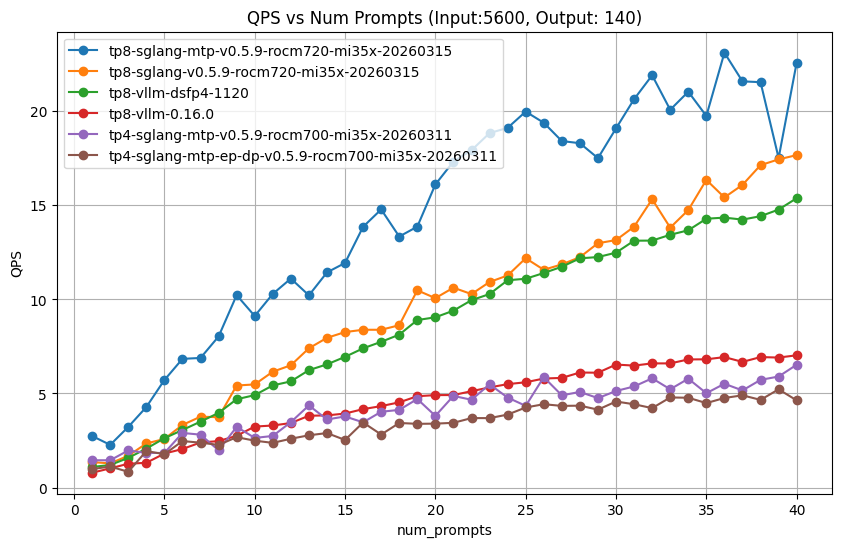

In [41]:
plt.figure(figsize=(10,6))

for val in cases:
    df_subset = df[df['others'] == val]

    avg_rt = (
        df_subset.groupby('concurrency')['request_throughput']
        .mean()
        .reset_index()
    )

    plt.plot(
        avg_rt['concurrency'],
        avg_rt['request_throughput'],
        marker='o',
        label=f'{clean(val)}'
    )

plt.title('QPS vs Num Prompts (Input:5600, Output: 140)')
plt.xlabel('num_prompts')
plt.ylabel('QPS')
plt.grid(True)
plt.legend()

plt.savefig("images/qps.png")   
plt.show()

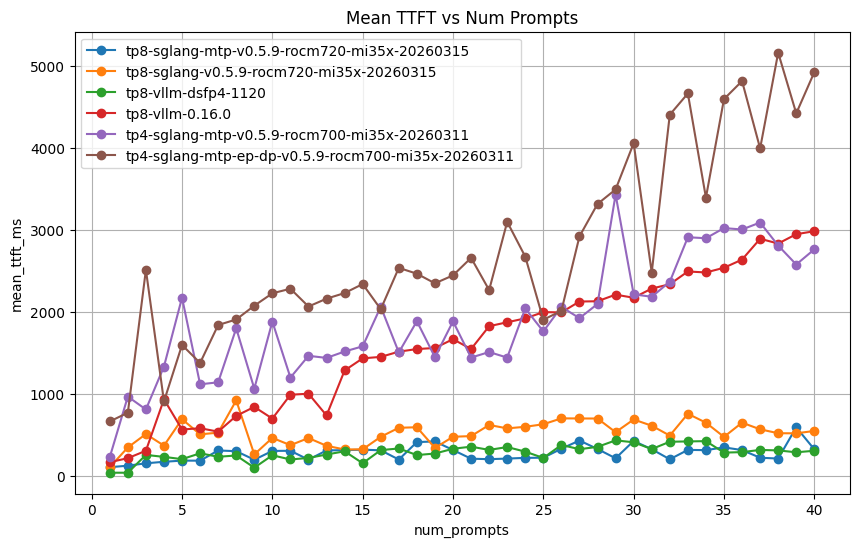

In [42]:
plt.figure(figsize=(10,6))

for val in cases:
    df_subset = df[df['others'] == val]

    avg_ttft = (
        df_subset.groupby('concurrency')['median_ttft_ms']
        .mean()
        .reset_index()
    )

    plt.plot(
        avg_ttft['concurrency'],
        avg_ttft['median_ttft_ms'],
        marker='o',
        label=f'{clean(val)}'
    )

plt.title('Mean TTFT vs Num Prompts')
plt.xlabel('num_prompts')
plt.ylabel('mean_ttft_ms')
plt.grid(True)
plt.legend()

plt.savefig("images/ttft.png")   
plt.show()

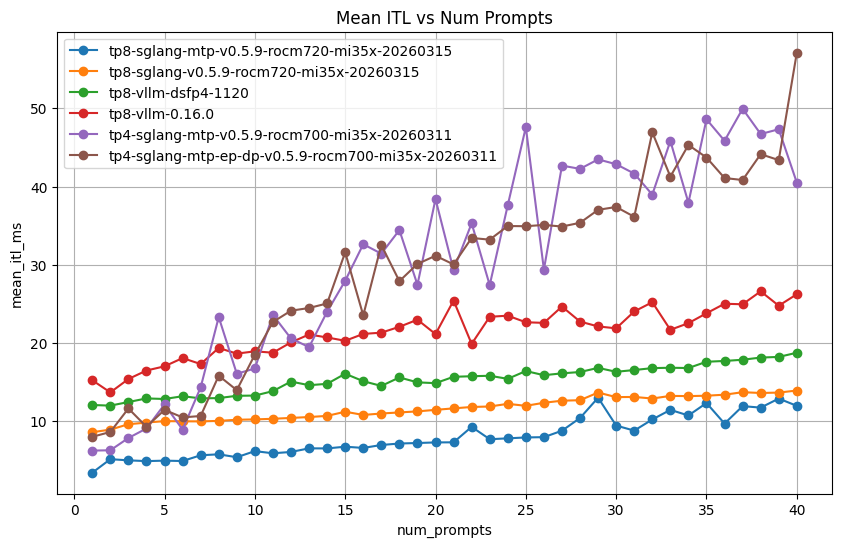

In [43]:
plt.figure(figsize=(10,6))

for val in cases:
    df_subset = df[df['others'] == val]

    avg_itl = (
        df_subset.groupby('concurrency')['mean_itl_ms']
        .mean()
        .reset_index()
    )

    plt.plot(
        avg_itl['concurrency'],
        avg_itl['mean_itl_ms'],
        marker='o',
        label=f'{clean(val)}'
    )

plt.title('Mean ITL vs Num Prompts')
plt.xlabel('num_prompts')
plt.ylabel('mean_itl_ms')
plt.grid(True)
plt.legend()

plt.savefig("images/itl.png")   
plt.show()

In [145]:
df.columns

Index(['task_id', 'random_output_len', 'median_itl_ms', 'mean_tpot_ms',
       'input_length', 'total_output_tokens', 'model_id', 'p99_tpot_ms',
       'p95_itl_ms', 'backend', 'mean_e2e_latency_ms',
       'total_token_throughput', 'total_input_vision_tokens', 'repeat_no',
       'input_throughput', 'date', 'total_input_tokens', 'std_tpot_ms',
       'completed', 'label', 'burstiness', 'p99_ttft_ms', 'median_tpot_ms',
       'concurrency', 'p99_e2e_latency_ms', 'mean_itl_ms', 'server_info',
       'duration', 'sharegpt_output_len', 'tag', 'others', 'max_concurrency',
       'mean_ttft_ms', 'num_prompts', 'dataset_name', 'request_rate',
       'output_throughput', 'endpoint_type', 'max_concurrent_requests',
       'base_url', 'max_concurrent_num', 'request_throughput', 'tokenizer_id',
       'accept_length', 'request_goodput', 'p90_e2e_latency_ms',
       'total_output_tokens_retokenized', 'total_throughput', 'reporter',
       'random_range_ratio', 'median_ttft_ms', 'repeats', 'p99_it